In [69]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.6f}'.format  # 保留6位小数
import os

# 固定 Python 与数值库的并行/哈希
os.environ["PYTHONHASHSEED"] = "42"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import numpy as np
import torch

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)      # 即便你现在用 CPU，写上也无害
    # 若用 GPU：强制确定性
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

import warnings
warnings.filterwarnings("ignore")
# 设置中文字体为 SimHei（黑体）·
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体 SimHei
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

PATH_EDGE_CSV = "../data/2023年城市边特征表.xlsx"  # 边表（含 Source/Target/Weight（车次）/距离（公里））
PATH_WEIGHT_CSV = "../data/dataset1.2013-2023地级市总货运量.xlsx"  # 285城市总货运量表（含 2013-2022（2023））


# 1.读取数据

## 2023年百度地图城市间车次流量数据 & 地级市货运量数据

In [70]:
# ==== 1) 读取并准备数据 ====
# 边特征表（车次流量、距离）
edge_df = pd.read_excel(PATH_EDGE_CSV,sheet_name="边原始特征")
#城市货运量及预测值
weight_df = pd.read_excel(PATH_WEIGHT_CSV,sheet_name="城市货运量")
weight_df.columns = weight_df.columns.astype(str).str.strip()

In [71]:
edge_df

,Source,Target,Weight,Distance
0,广州市,乌鲁木齐市,0.571429,3287.269417
1,乌鲁木齐市,广州市,0.642857,3287.269417
2,上海市,乌鲁木齐市,1.714286,3271.311297
3,牡丹江市,昆明市,0.642857,3260.019497
4,昆明市,哈尔滨市,1.500000,3147.193986
...,...,...,...,...
31417,湘潭市,株洲市,212.357143,18.701533
31418,嘉峪关市,酒泉市,378.714286,18.148187
31419,酒泉市,嘉峪关市,481.928571,18.148187
31420,鄂州市,黄冈市,346.071429,7.228916


In [72]:
edge_df.sort_values('Distance')

,Source,Target,Weight,Distance
31421,黄冈市,鄂州市,455.142857,7.228916
31420,鄂州市,黄冈市,346.071429,7.228916
31418,嘉峪关市,酒泉市,378.714286,18.148187
31419,酒泉市,嘉峪关市,481.928571,18.148187
31416,株洲市,湘潭市,192.571429,18.701533
...,...,...,...,...
4,昆明市,哈尔滨市,1.500000,3147.193986
3,牡丹江市,昆明市,0.642857,3260.019497
2,上海市,乌鲁木齐市,1.714286,3271.311297
1,乌鲁木齐市,广州市,0.642857,3287.269417


In [73]:
weight_df

,city,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,北京市,24651,25416,19044,19972,19374,20278,22325,21789,23075,18549,19399.000009
1,天津市,31985,31130,33724,32841,34720,34711,36710,32261,34527,30382,33741.999995
2,石家庄市,34490,24536,36954,40639,45802,52911,51105,51258,52602,51420,56250.909648
3,唐山市,43043,33479,36358,38965,41340,44150,42220,42295,47925,39204,46636.066664
4,秦皇岛市,5225,4773,5276,6300,6684,6934,6697,6707,7808,6102,7464.318624
...,...,...,...,...,...,...,...,...,...,...,...,...
280,固原市,4069,4624,5730,6212,5570,5569,5568,5567,5566,5566,7994.257421
281,中卫市,2144,2176,2178,7571,5403,6428,6619,6858,6713,6800,7637.550040
282,乌鲁木齐市,17853,11365,14793,14938,17145,19500,19303,9243,4711,8898,36013.909712
283,吐鲁番市,1684,1684,1682,1691,1645,1871,1852,887,667,1288,11954.596610


## 将百度地图线路按照距离添加距离分组（distance_group）

In [23]:
# # 增加列distance_group:将2023年各个线路的车次流量按照距离分组为5+1组（额外一组为城市内）
# bins = [0, 50, 100, 200, 400, np.inf]
# labels = ['0-50','50-100', '100-200', '200-400', '400+']

# # 先按距离分组，得到 Categorical
# edge_df['distance_group'] = pd.cut(edge_df['Distance'], bins=bins, labels=labels, right=False)#左闭右开

# # ✅ 给 Categorical 增加一个新类别：intra-city
# edge_df['distance_group'] = edge_df['distance_group'].cat.add_categories(['intra-city'])

# # ✅ 再把 Source == Target 的行改成城市内货运
# edge_df.loc[edge_df['Source'] == edge_df['Target'], 'distance_group'] = 'intra-city'

# edge_df

In [78]:
import numpy as np
import pandas as pd

def add_distance_group(
    df: pd.DataFrame,
    distance_col: str = "Distance",
    source_col: str = "Source",
    target_col: str = "Target",
    bins = (0, 50, 100, 200, 400, np.inf),
    labels = ("10-50", "50-100", "100-200", "200-400", "400+"),
    intra_label: str = "intra-city",
    right: bool = False,          # False = 左闭右开，与你现在一致
    include_lowest: bool = True,   # 让最小值也能落进第一个bin
    ordered: bool = True,          # 是否把分类设为有序
    out_col: str = "distance_group",
    inplace: bool = False
) -> pd.DataFrame:
    """
    给边表增加距离分组列 out_col：
    - 先按 Distance 分 bin
    - 再把 Source==Target 的记录强制标记为 intra-city
    """
    if not inplace:
        df = df.copy()

    # --- basic checks ---
    for col in (distance_col, source_col, target_col):
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in df.")

    if len(bins) - 1 != len(labels):
        raise ValueError("len(labels) must equal len(bins)-1.")

    # Distance 必须可转为数值
    df[distance_col] = pd.to_numeric(df[distance_col], errors="coerce")

    # 先分箱（得到 Categorical）
    cat = pd.cut(
        df[distance_col],
        bins=bins,
        labels=labels,
        right=right,
        include_lowest=include_lowest
    )

    # 增加 intra-city 类别
    cat = cat.cat.add_categories([intra_label])

    # 写入列
    df[out_col] = cat

    # 城市内：Source==Target 强制覆盖
    intra_mask = df[source_col].astype(str) == df[target_col].astype(str)
    df.loc[intra_mask, out_col] = intra_label

    # 可选：设置为有序分类（把 intra-city 放在最前）
    if ordered:
        new_cats = [intra_label] + list(labels)
        df[out_col] = pd.Categorical(df[out_col], categories=new_cats, ordered=True)

    return df
edge_df = add_distance_group(edge_df)
edge_df


,Source,Target,Weight,Distance,distance_group
0,广州市,乌鲁木齐市,0.571429,3287.269417,400+
1,乌鲁木齐市,广州市,0.642857,3287.269417,400+
2,上海市,乌鲁木齐市,1.714286,3271.311297,400+
3,牡丹江市,昆明市,0.642857,3260.019497,400+
4,昆明市,哈尔滨市,1.500000,3147.193986,400+
...,...,...,...,...,...
31417,湘潭市,株洲市,212.357143,18.701533,10-50
31418,嘉峪关市,酒泉市,378.714286,18.148187,10-50
31419,酒泉市,嘉峪关市,481.928571,18.148187,10-50
31420,鄂州市,黄冈市,346.071429,7.228916,10-50


## 计算各距离段分布（各距离段的加权平均距离）以便计算碳排放（货运量*距离*碳排放因子）

In [79]:
# # 假设 edge_df 至少含列：['Source','Target','Distance','Weight','distance_group']
# df = edge_df.copy()

# # 统一分组标签
# df['distance_group'] = df['distance_group'].astype(str).str.replace('–','-')

# # 1) 计算每个距离段的加权车次与占比
# grp = (df.groupby('distance_group', as_index=False)
#          .agg(trips=('Weight','sum')))

# grp['share'] = grp['trips'] / grp['trips'].sum()

# # 2) 计算每个距离段的加权平均距离（用 Weight 做权重）
# wmean = (df.groupby('distance_group', as_index=False)
#            .apply(lambda g: pd.Series({
#                'avg_distance_w': np.average(g['Distance'], weights=g['Weight'])
#            }))
#         )

# dist_summary = grp.merge(wmean, on='distance_group', how='left')


# # 更改排列顺序
# order = ["intra-city", "0-50", "50-100", "100-200", "200-400", "400+"]

# # 设为有序分类
# dist_summary["distance_group"] = pd.Categorical(
#     dist_summary["distance_group"],
#     categories=order,
#     ordered=True
# )

# # 按逻辑顺序排序输出
# dist_summary = dist_summary.sort_values("distance_group")

# print("各距离段分布（加权）：")
# print(dist_summary)
# dist_summary.to_csv("../data/2023不同里程等级车次及占比.csv", index=False, encoding="utf_8_sig")

In [80]:
# df = edge_df.copy()
# df['distance_group'] = df['distance_group'].astype(str).str.replace('–','-')

# # 例：如果你有每个距离段的平均载重 payload_map（吨/车）
# payload_map ={"0-50": 5.0,
#     "50-100": 10.0,
#     "100-200": 15.0,
#     "200-400": 25.0,
#     "400+": 30.0,
#     "intra-city":5.0}
# df['ton_w'] = df['Weight'] * df['distance_group'].map(payload_map)

# # 吨份额
# grp = df.groupby('distance_group', as_index=False).agg(tons=('ton_w','sum'))
# grp['share_ton'] = grp['tons'] / grp['tons'].sum()

# # 用“吨”做权重算代表距离（同时建议对 400+ 做截尾）
# def wavg_trim(g, wcol='ton_w', xcol='Distance', q=0.95):
#     x = g[xcol].to_numpy()
#     w = g[wcol].to_numpy()
#     cap = np.quantile(x, q)
#     m = x <= cap
#     return np.average(x[m], weights=w[m])

# wrep = df.groupby('distance_group').apply(lambda g: pd.Series({
#     'd_rep': wavg_trim(g, q=0.95)  # 或者用加权中位数
# })).reset_index()

# dist_summary2 = grp.merge(wrep, on='distance_group')
# print("各距离段分布（加权）：")
# print(dist_summary2.sort_values('distance_group'))

In [82]:
df = edge_df.copy()
df['distance_group'] = df['distance_group'].astype(str).str.replace('–','-', regex=False)

# 例：每个距离段的平均载重 payload_map（吨/车）
payload_map = {
    "intra-city": 5.0,
    "10-50": 5.0,
    "50-100": 10.0,
    "100-200": 15.0,
    "200-400": 25.0,
    "400+": 30.0
}

# 吨权重
df['ton_w'] = df['Weight'] * df['distance_group'].map(payload_map)

# 吨份额
grp = df.groupby('distance_group', as_index=False).agg(tons=('ton_w','sum'))
grp['share_ton'] = grp['tons'] / grp['tons'].sum()

# -------------------------
# 吨权重加权中位数（weighted median）
# -------------------------
def weighted_median(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[m], w[m]
    if len(x) == 0:
        return np.nan
    idx = np.argsort(x)
    x, w = x[idx], w[idx]
    cw = np.cumsum(w)
    cutoff = 0.5 * w.sum()
    return x[np.searchsorted(cw, cutoff)]

# -------------------------
# 截尾加权均值（对非400+段继续用你原来的方法）
# -------------------------
def wavg_trim(g, wcol='ton_w', xcol='Distance', q=0.95):
    x = g[xcol].to_numpy()
    w = g[wcol].to_numpy()
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[m], w[m]
    if len(x) == 0:
        return np.nan
    cap = np.quantile(x, q)
    keep = x <= cap
    # 防止极端情况下全被截掉
    if keep.sum() == 0:
        return np.average(x, weights=w)
    return np.average(x[keep], weights=w[keep])

# -------------------------
# 代表距离：除 400+ 用截尾均值；400+ 用吨权重加权中位数
# -------------------------
def d_rep_by_group(g, group_name, q=0.95):
    if group_name == "400+":
        return weighted_median(g['Distance'].to_numpy(), g['ton_w'].to_numpy())
    else:
        return wavg_trim(g, wcol='ton_w', xcol='Distance', q=q)

wrep = (df.groupby('distance_group')
          .apply(lambda g: pd.Series({
              'd_rep': d_rep_by_group(g, g.name, q=0.95)
          }))
          .reset_index())

dist_summary2 = grp.merge(wrep, on='distance_group', how='left')

# 更改排列顺序
order = ["intra-city", "10-50", "50-100", "100-200", "200-400", "400+"]

# 设为有序分类
dist_summary2["distance_group"] = pd.Categorical(
    dist_summary2["distance_group"],
    categories=order,
    ordered=True
)

# 按逻辑顺序排序输出
dist_summary2 = dist_summary2.sort_values("distance_group")

print("各距离段分布（加权）：")
print(dist_summary2)

# 全国等效平均运距
dist_summary2["contrib_km"] = dist_summary2["share_ton"] * dist_summary2["d_rep"]
print("\n全国等效平均运距 (km/吨):", dist_summary2["contrib_km"].sum())



各距离段分布（加权）：
  distance_group           tons  share_ton      d_rep
5     intra-city 7041801.071429   0.218155  25.000000
0          10-50  504282.142857   0.015623  33.283130
4         50-100 3686905.000000   0.114220  74.107188
1        100-200 7473923.571429   0.231542 140.889299
2        200-400 7454576.785714   0.230943 266.275492
3           400+ 6117364.285714   0.189516 642.779092

全国等效平均运距 (km/吨): 230.37175840502834


In [51]:
# dist_summary2.to_csv("../data/2023不同里程等级货运量及占比.csv", index=False, encoding="utf_8_sig")

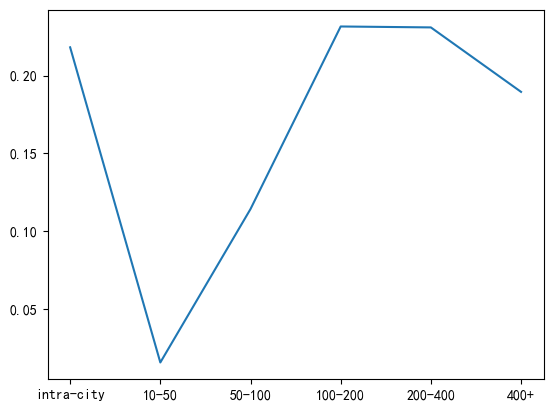

In [83]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot(dist_summary2["distance_group"], dist_summary2["share_ton"])  # Plot some data on the Axes.
plt.show()                           # Show the figure.

In [92]:
import numpy as np
import pandas as pd

# ===== 输入 =====
df = edge_df.copy()

# 里程段 → 每车次平均载货量 Q_g（吨/车）
Q = {
    'intra-city': 5.0,
    "10-50": 5.0,
    "50-100": 10.0,
    "100-200": 15.0,
    "200-400": 25.0,
    "400+": 30.0
}
groups = list(Q.keys())  # 固定列顺序

# 你给定的“全国目标吨份额”（顺序必须与 groups 一致）
share_target = pd.Series(
    [0.146268657, 0.128358209, 0.208955224, 0.197014925, 0.194029851, 0.125373134],
    index=groups,
    name="share_target"
)

# 1) 统一分组标签
df["distance_group"] = df["distance_group"].astype(str).str.replace("–", "-", regex=False)

# 2) 仅保留目标分组
df = df[df["distance_group"].isin(groups)].copy()

# 3) 赋 Q_g，并计算“吨”（Weight 为车次）
df["Q_g"]  = df["distance_group"].map(Q)
df["tons"] = df["Weight"] * df["Q_g"]

# 4) 各城市×距离段汇总成“吨矩阵”
mat_tons = (df.groupby(["Source","distance_group"], as_index=False)["tons"].sum()
              .rename(columns={"Source":"city"})
              .pivot(index="city", columns="distance_group", values="tons")
              .reindex(columns=groups)            # 按既定顺序
              .fillna(0.0))

# 5) 原始：城市内归一化（城市距离段吨占比）
ton_share_matrix_orig = mat_tons.div(mat_tons.sum(axis=1), axis=0).fillna(0.0)

# ===== 核心新增：按全国目标曲线做“距离段缩放校准” =====

# A) 全国原始吨份额（由 mat_tons 汇总得到）
total_ton_by_group = mat_tons.sum(axis=0)  # 每个距离段全国吨数
share_orig = (total_ton_by_group / total_ton_by_group.sum()).rename("share_orig")

# B) 计算缩放因子 s_g = target / orig
# 防止 orig=0（理论上不会，但加个保护）
eps = 1e-12
scale = (share_target / (share_orig + eps)).rename("scale_factor")

# C) 对每个城市的各段吨数做缩放
mat_tons_adj = mat_tons.mul(scale, axis=1)

# D) 城市内重新归一化：得到“校准后的城市吨占比”
ton_share_matrix_adj = mat_tons_adj.div(mat_tons_adj.sum(axis=1), axis=0).fillna(0.0)

# E) 校准后全国对照（应接近 share_target）
total_ton_by_group_adj = mat_tons_adj.sum(axis=0)
share_overall_adj = (total_ton_by_group_adj / total_ton_by_group_adj.sum()).rename("share_overall_adj")

# 6) 若需要长表（便于 merge / 画图）——原始 & 校准后都给
ton_share_long_orig = (ton_share_matrix_orig
                       .reset_index()
                       .melt(id_vars="city", var_name="distance_group", value_name="ton_share_orig"))

ton_share_long_adj = (ton_share_matrix_adj
                      .reset_index()
                      .melt(id_vars="city", var_name="distance_group", value_name="ton_share_adj"))

ton_share_long = ton_share_long_orig.merge(
    ton_share_long_adj, on=["city","distance_group"], how="left"
)

# ===== 输出（保持你原来的风格，同时补充校准信息） =====
print("【矩阵-原始】每个城市5+1个距离段的载货量占比：")
print(ton_share_matrix_orig.head())

print("\n【矩阵-校准后】每个城市5+1个距离段的载货量占比：")
print(ton_share_matrix_adj.head())

print("\n【长表】前几行（含原始/校准后）：")
print(ton_share_long.head())

print("\n【全国对照】原始 share_orig：")
print(share_orig)

print("\n【全国对照】目标 share_target：")
print(share_target)

print("\n【全国对照】校准后 share_overall_adj（应≈目标）：")
print(share_overall_adj)

print("\n【缩放因子】scale_factor = target/orig：")
print(scale)


【矩阵-原始】每个城市5+1个距离段的载货量占比：
distance_group  intra-city    10-50   50-100  100-200  200-400     400+
city                                                                   
七台河市              0.027199 0.000000 0.287523 0.170734 0.209141 0.305404
三明市               0.134643 0.000000 0.085531 0.491185 0.214362 0.074279
三门峡市              0.051373 0.038187 0.000000 0.159655 0.547654 0.203131
上海市               0.572076 0.000000 0.144142 0.096900 0.068252 0.118630
上饶市               0.066339 0.000000 0.051358 0.169560 0.522736 0.190008

【矩阵-校准后】每个城市5+1个距离段的载货量占比：
distance_group  intra-city    10-50   50-100  100-200  200-400     400+
city                                                                   
七台河市              0.017087 0.000000 0.492849 0.136119 0.164639 0.189306
三明市               0.100988 0.000000 0.175039 0.467534 0.201470 0.054969
三门峡市              0.031936 0.290904 0.000000 0.125954 0.426612 0.124594
上海市               0.443156 0.000000 0.304661 0.095260 0.066252 0.090672
上饶市       

## 计算每个城市5+1个距离段的载货量吨数占比

In [85]:
# ===== 输入 =====
df = edge_df.copy()

# 里程段 → 每车次平均载货量 Q_g（吨/车）
Q = {
    'intra-city':5.0,
    "10-50": 5.0,
    "50-100": 10.0,
    "100-200": 15.0,
    "200-400": 25.0,
    "400+": 30.0
}
groups = list(Q.keys())  # 固定列顺序

# 1) 统一分组标签（把中文破折号替换为半角连字符，便于匹配）
df["distance_group"] = df["distance_group"].astype(str).str.replace("–", "-")

# 2) 仅保留这5个目标分组（可选，但建议，避免脏值）
df = df[df["distance_group"].isin(groups)]

# 3) 赋 Q_g，并计算“吨”（Weight 为车次）
df["Q_g"]  = df["distance_group"].map(Q)
df["tons"] = df["Weight"] * df["Q_g"]

# 4) 各城市×距离段汇总成“吨矩阵”
mat_tons = (df.groupby(["Source","distance_group"], as_index=False)["tons"].sum()
              .rename(columns={"Source":"city"})
              .pivot(index="city", columns="distance_group", values="tons")
              .reindex(columns=groups)            # 按既定顺序
              .fillna(0.0))

# 5) 行归一化：得到“每个城市在5个距离段的**载货量占比**”
ton_share_matrix = mat_tons.div(mat_tons.sum(axis=1), axis=0).fillna(0.0)

# 6) 若需要长表（便于 merge / 画图）
ton_share_long = (ton_share_matrix
                  .reset_index()
                  .melt(id_vars="city", var_name="distance_group", value_name="ton_share"))

# ===== 可选：也算一个“全网络”的总载货量占比（对照） =====
total_ton_by_group = mat_tons.sum(axis=0)
ton_share_overall = (total_ton_by_group / total_ton_by_group.sum()).rename("ton_share_overall")

print("【矩阵】每个城市5+1个距离段的载货量占比：")
print(ton_share_matrix.head())

print("\n【长表】前几行：")
print(ton_share_long.head())

print("\n【全网络对照】按载货量占比：")
print(ton_share_overall)


【矩阵】每个城市5+1个距离段的载货量占比：
distance_group  intra-city    10-50   50-100  100-200  200-400     400+
city                                                                   
七台河市              0.027199 0.000000 0.287523 0.170734 0.209141 0.305404
三明市               0.134643 0.000000 0.085531 0.491185 0.214362 0.074279
三门峡市              0.051373 0.038187 0.000000 0.159655 0.547654 0.203131
上海市               0.572076 0.000000 0.144142 0.096900 0.068252 0.118630
上饶市               0.066339 0.000000 0.051358 0.169560 0.522736 0.190008

【长表】前几行：
   city distance_group  ton_share
0  七台河市     intra-city   0.027199
1   三明市     intra-city   0.134643
2  三门峡市     intra-city   0.051373
3   上海市     intra-city   0.572076
4   上饶市     intra-city   0.066339

【全网络对照】按载货量占比：
distance_group
intra-city   0.218155
10-50        0.015623
50-100       0.114220
100-200      0.231542
200-400      0.230943
400+         0.189516
Name: ton_share_overall, dtype: float64


In [86]:
df

,Source,Target,Weight,Distance,distance_group,Q_g,tons
0,广州市,乌鲁木齐市,0.571429,3287.269417,400+,30.000000,17.142857
1,乌鲁木齐市,广州市,0.642857,3287.269417,400+,30.000000,19.285714
2,上海市,乌鲁木齐市,1.714286,3271.311297,400+,30.000000,51.428571
3,牡丹江市,昆明市,0.642857,3260.019497,400+,30.000000,19.285714
4,昆明市,哈尔滨市,1.500000,3147.193986,400+,30.000000,45.000000
...,...,...,...,...,...,...,...
31417,湘潭市,株洲市,212.357143,18.701533,10-50,5.000000,1061.785714
31418,嘉峪关市,酒泉市,378.714286,18.148187,10-50,5.000000,1893.571429
31419,酒泉市,嘉峪关市,481.928571,18.148187,10-50,5.000000,2409.642857
31420,鄂州市,黄冈市,346.071429,7.228916,10-50,5.000000,1730.357143


In [87]:
# ton_share_long[ton_share_long["city"]=="北京市"]["ton_share"].sum() 
ton_share_matrix

distance_group,intra-city,10-50,50-100,100-200,200-400,400+
city,,,,,,
七台河市,0.027199,0.000000,0.287523,0.170734,0.209141,0.305404
三明市,0.134643,0.000000,0.085531,0.491185,0.214362,0.074279
三门峡市,0.051373,0.038187,0.000000,0.159655,0.547654,0.203131
上海市,0.572076,0.000000,0.144142,0.096900,0.068252,0.118630
上饶市,0.066339,0.000000,0.051358,0.169560,0.522736,0.190008
...,...,...,...,...,...,...
黄山市,0.140131,0.000000,0.083916,0.529149,0.209963,0.036841
黄石市,0.043624,0.122759,0.296014,0.131027,0.256204,0.150374
黑河市,0.175050,0.000000,0.000000,0.000000,0.025511,0.799439


In [93]:
ton_share_matrix_adj

distance_group,intra-city,10-50,50-100,100-200,200-400,400+
city,,,,,,
七台河市,0.017087,0.000000,0.492849,0.136119,0.164639,0.189306
三明市,0.100988,0.000000,0.175039,0.467534,0.201470,0.054969
三门峡市,0.031936,0.290904,0.000000,0.125954,0.426612,0.124594
上海市,0.443156,0.000000,0.304661,0.095260,0.066252,0.090672
上饶市,0.052477,0.000000,0.110848,0.170218,0.518156,0.148301
...,...,...,...,...,...,...
黄山市,0.104570,0.000000,0.170860,0.501111,0.196333,0.027126
黄石市,0.014584,0.502893,0.270008,0.055588,0.107326,0.049600
黑河市,0.175788,0.000000,0.000000,0.000000,0.032103,0.792110


In [89]:
# 2022地区货运量（万吨）
weight_df[["city","2023"]]

,city,2023
0,北京市,19399.000009
1,天津市,33741.999995
2,石家庄市,56250.909648
3,唐山市,46636.066664
4,秦皇岛市,7464.318624
...,...,...
280,固原市,7994.257421
281,中卫市,7637.550040
282,乌鲁木齐市,36013.909712
283,吐鲁番市,11954.596610


## 用“每城自己的 ton_share_long”拆分 2023 总货量 

In [90]:
ton_share_long

,city,distance_group,ton_share
0,七台河市,intra-city,0.027199
1,三明市,intra-city,0.134643
2,三门峡市,intra-city,0.051373
3,上海市,intra-city,0.572076
4,上饶市,intra-city,0.066339
...,...,...,...
1705,黄山市,400+,0.036841
1706,黄石市,400+,0.150374
1707,黑河市,400+,0.799439
1708,齐齐哈尔市,400+,0.135770


In [101]:
#选择23年的总货量
# city_df_2023 = weight_df[["city","填充2023"]].copy()#
city_df_2023 = (
    weight_df[["city", "2023"]]
    .rename(columns={"2023": "total_ton"})
    .assign(year=2023)
    .loc[:, ["city", "year", "total_ton"]]
)

city_dist_df_2023 = (
    city_df_2023
    .merge(ton_share_long, on="city", how="left")
    .assign(weight_distance=lambda d: d["total_ton"] * d["ton_share_adj"])
)


city_dist_df_2023 = (city_df_2023.merge(ton_share_long, on="city", how="left")
                                   .assign(weight_distance=lambda d: d["total_ton"] * d["ton_share_adj"]))

city_dist_df_2023

,city,year,total_ton,distance_group,ton_share_orig,ton_share_adj,weight_distance
0,北京市,2023,19399.000009,intra-city,0.407323,0.269966,5237.075531
1,北京市,2023,19399.000009,10-50,0.034243,0.278118,5395.217434
2,北京市,2023,19399.000009,50-100,0.000000,0.000000,0.000000
3,北京市,2023,19399.000009,100-200,0.412020,0.346555,6722.818816
4,北京市,2023,19399.000009,200-400,0.054448,0.045220,877.219386
...,...,...,...,...,...,...,...
1705,哈密市,2023,34773.493677,10-50,0.000000,0.000000,0.000000
1706,哈密市,2023,34773.493677,50-100,0.000000,0.000000,0.000000
1707,哈密市,2023,34773.493677,100-200,0.000000,0.000000,0.000000
1708,哈密市,2023,34773.493677,200-400,0.000000,0.000000,0.000000


In [95]:
city_dist_df_2023.to_csv("../data/dataset2_2023地级市不同里程等级货运量_adj.csv", index=False, encoding="utf_8_sig")

 ## 百度地图23年城市车流数据计算各个地级市在不同里程的货运量占比乘以2023年地级市总货运量获得数据集2

In [97]:
pip install pypinyin

   ---------------------------------------- 0.0/840.2 kB ? eta -:--:--
   ---------------------------------------- 10.2/840.2 kB ? eta -:--:--
   - ------------------------------------- 41.0/840.2 kB 653.6 kB/s eta 0:00:02
   ---- --------------------------------- 102.4/840.2 kB 837.8 kB/s eta 0:00:01
   -------- ------------------------------- 174.1/840.2 kB 1.0 MB/s eta 0:00:01
   ------------- -------------------------- 286.7/840.2 kB 1.4 MB/s eta 0:00:01
   --------------------- ------------------ 460.8/840.2 kB 1.9 MB/s eta 0:00:01
   --------------------------------- ------ 706.6/840.2 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 840.2/840.2 kB 2.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [102]:
import re
import pandas as pd
from pypinyin import lazy_pinyin

# ===== 1) 惯用英文/国际常用（可继续往里加）=====
SPECIAL = {
    # 直辖市/特大城市（常用写法）
    "北京市": "Beijing",
    "天津市": "Tianjin",
    "上海市": "Shanghai",
    "重庆市": "Chongqing",

    "广州市": "Guangzhou",
    "深圳市": "Shenzhen",
    "南京市": "Nanjing",
    "杭州市": "Hangzhou",
    "苏州市": "Suzhou",
    "武汉市": "Wuhan",
    "成都市": "Chengdu",
    "西安市": "Xi'an",      # 常用 Xi'an
    "郑州市": "Zhengzhou",
    "长沙市": "Changsha",
    "昆明市": "Kunming",

    # 东北/华北常见“惯用”不完全等于规则拼音的
    "哈尔滨市": "Harbin",
    "长春市": "Changchun",
    "沈阳市": "Shenyang",
    "大连市": "Dalian",
    "齐齐哈尔市": "Qiqihar",

    # 沿海与常见旅游/口岸城市
    "青岛市": "Qingdao",
    "厦门市": "Xiamen",
    "福州市": "Fuzhou",
    "宁波市": "Ningbo",
    "温州市": "Wenzhou",
    "珠海市": "Zhuhai",
    "汕头市": "Shantou",

    # 西北/少数民族地区常见英文名
    "乌鲁木齐市": "Urumqi",
    "吐鲁番市": "Turpan",      # 常用 Turpan（也有人用 Turfan）
    "哈密市": "Hami",
    "呼和浩特市": "Hohhot",
    "鄂尔多斯市": "Ordos",
    "呼伦贝尔市": "Hulunbuir",
    "巴彦淖尔市": "Bayannur",
    "乌兰察布市": "Ulanqab",
}

# ===== 2) 后缀清理（你这份基本都是“市”）=====
SUFFIX_RE = re.compile(r"(市)$")

def cn_to_en_international(cn: str) -> str:
    if pd.isna(cn):
        return cn
    cn = str(cn).strip()

    # 先走惯用英文
    if cn in SPECIAL:
        return SPECIAL[cn]

    # 否则走规则拼音兜底（保证不会缺失）
    base = SUFFIX_RE.sub("", cn)
    py = "".join(lazy_pinyin(base))  # 无空格
    return py[:1].upper() + py[1:]   # 首字母大写

# ===== 3) 应用到你的边表 df（Source/Target）=====
city_dist_df_2023["city_en"] = city_dist_df_2023["city"].apply(cn_to_en_international)



city_dist_df_2023


,city,year,total_ton,distance_group,ton_share_orig,ton_share_adj,weight_distance,city_en
0,北京市,2023,19399.000009,intra-city,0.407323,0.269966,5237.075531,Beijing
1,北京市,2023,19399.000009,10-50,0.034243,0.278118,5395.217434,Beijing
2,北京市,2023,19399.000009,50-100,0.000000,0.000000,0.000000,Beijing
3,北京市,2023,19399.000009,100-200,0.412020,0.346555,6722.818816,Beijing
4,北京市,2023,19399.000009,200-400,0.054448,0.045220,877.219386,Beijing
...,...,...,...,...,...,...,...,...
1705,哈密市,2023,34773.493677,10-50,0.000000,0.000000,0.000000,Hami
1706,哈密市,2023,34773.493677,50-100,0.000000,0.000000,0.000000,Hami
1707,哈密市,2023,34773.493677,100-200,0.000000,0.000000,0.000000,Hami
1708,哈密市,2023,34773.493677,200-400,0.000000,0.000000,0.000000,Hami


In [103]:
city_dist_df_2023["weight_distance"].sum()

4020950.0000820924

In [105]:
city_dist_df_2023.to_csv("../output/dataset2.MultiDistance_2023地级市不同里程等级货运量.csv", index=False, encoding="utf_8_sig")

In [106]:
city_dist_df_2023.to_excel(
    "../out/dataset2.MultiDistance_2023地级市不同里程等级货运量.xlsx",
    index=False,
    engine="openpyxl"
)
